In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/Maternal Health Risk Data Set.csv")

risk_mapping = {
    "low risk": 0,
    "mid risk": 1,
    "high risk": 2
}
df["RiskLabel"] = df["RiskLevel"].str.lower().map(risk_mapping)

final_df = df[
    ["Age", "SystolicBP", "DiastolicBP", "BS", "BodyTemp", "HeartRate", "RiskLabel"]
]

final_df.to_csv("../data/processed/final_maternal_preterm_risk.csv", index=False)

final_df.head()


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLabel
0,25,130,80,15.0,98.0,86,2
1,35,140,90,13.0,98.0,70,2
2,29,90,70,8.0,100.0,80,2
3,30,140,85,7.0,98.0,70,2
4,35,120,60,6.1,98.0,76,0


In [3]:
import pandas as pd

df = pd.read_csv("../data/processed/final_maternal_preterm_risk.csv")
df.head()


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLabel
0,25,130,80,15.0,98.0,86,2
1,35,140,90,13.0,98.0,70,2
2,29,90,70,8.0,100.0,80,2
3,30,140,85,7.0,98.0,70,2
4,35,120,60,6.1,98.0,76,0


In [4]:
df.shape
df.columns


Index(['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate',
       'RiskLabel'],
      dtype='object')

In [5]:
df["RiskLabel"].value_counts()


RiskLabel
0    406
1    336
2    272
Name: count, dtype: int64

In [6]:
df.describe()


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLabel
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775,0.867850
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702,0.807353
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000,0.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000,0.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000,1.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000,2.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000,2.000000


In [7]:
df.groupby("RiskLabel").mean()


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
RiskLabel,,,,,,
0,26.869458,105.866995,72.534483,7.220271,98.368966,72.770936
1,28.363095,113.154762,74.232143,7.795744,98.833333,74.175595
2,36.216912,124.194853,85.073529,12.122610,98.899265,76.742647


In [8]:
df.corr()


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLabel
Age,1.000000,0.416045,0.398026,0.473284,-0.255323,0.079798,0.267225
SystolicBP,0.416045,1.000000,0.787006,0.425172,-0.286616,-0.023108,0.396473
DiastolicBP,0.398026,0.787006,1.000000,0.423824,-0.257538,-0.046151,0.346649
BS,0.473284,0.425172,0.423824,1.000000,-0.103493,0.142867,0.569942
BodyTemp,-0.255323,-0.286616,-0.257538,-0.103493,1.000000,0.098771,0.163984
HeartRate,0.079798,-0.023108,-0.046151,0.142867,0.098771,1.000000,0.194312
RiskLabel,0.267225,0.396473,0.346649,0.569942,0.163984,0.194312,1.000000


In [9]:
from sklearn.model_selection import train_test_split

X = df.drop("RiskLabel", axis=1)
y = df["RiskLabel"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape


((811, 6), (203, 6))

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
from sklearn.metrics import classification_report

rf_pred = rf.predict(X_test)
print("Random Forest\n")
print(classification_report(y_test, rf_pred))


Random Forest

              precision    recall  f1-score   support

           0       0.87      0.81      0.84        81
           1       0.81      0.81      0.81        67
           2       0.88      0.96      0.92        55

    accuracy                           0.85       203
   macro avg       0.85      0.86      0.86       203
weighted avg       0.85      0.85      0.85       203



In [13]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [14]:
gb_pred = gb.predict(X_test)
print("Gradient Boosting\n")
print(classification_report(y_test, gb_pred))


Gradient Boosting

              precision    recall  f1-score   support

           0       0.83      0.83      0.83        81
           1       0.77      0.73      0.75        67
           2       0.90      0.95      0.92        55

    accuracy                           0.83       203
   macro avg       0.83      0.83      0.83       203
weighted avg       0.83      0.83      0.83       203



In [15]:
from sklearn.svm import SVC

svm = SVC(
    kernel="rbf",
    class_weight="balanced"
)

svm.fit(X_train_scaled, y_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [16]:
svm_pred = svm.predict(X_test_scaled)
print("SVM\n")
print(classification_report(y_test, svm_pred))


SVM

              precision    recall  f1-score   support

           0       0.66      0.83      0.73        81
           1       0.63      0.36      0.46        67
           2       0.79      0.91      0.85        55

    accuracy                           0.69       203
   macro avg       0.69      0.70      0.68       203
weighted avg       0.69      0.69      0.67       203



In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=42, class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),
    "SVM": SVC(
        kernel="rbf", class_weight="balanced"
    )
}


In [18]:
from sklearn.metrics import recall_score, f1_score
import pandas as pd

results = []

for name, model in models.items():
    
    # Use scaled data only for LR & SVM
    if name in ["Logistic Regression", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    recall_high = recall_score(y_test, y_pred, labels=[2], average=None)[0]
    f1_high = f1_score(y_test, y_pred, labels=[2], average=None)[0]
    
    results.append({
        "Model": name,
        "Recall_HighRisk": recall_high,
        "F1_HighRisk": f1_high
    })


In [19]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by="Recall_HighRisk", ascending=False
)

results_df


,Model,Recall_HighRisk,F1_HighRisk
1,Random Forest,0.963636,0.921739
2,Gradient Boosting,0.945455,0.920354
3,SVM,0.909091,0.847458
0,Logistic Regression,0.854545,0.803419


In [20]:
best_model_name = results_df.iloc[0]["Model"]
best_model_name


'Random Forest'

In [22]:
from sklearn.ensemble import RandomForestClassifier

best_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

best_model.fit(X_train, y_train)


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
})

importance.sort_values(by="Importance", ascending=False)


,Feature,Importance
3,BS,0.365455
1,SystolicBP,0.183485
0,Age,0.163258
2,DiastolicBP,0.124575
5,HeartRate,0.103958
4,BodyTemp,0.059269


In [24]:
sample = X_test.iloc[[0]]
sample


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
71,29,130,70,7.7,98.0,78


In [25]:
probs = best_model.predict_proba(sample)
probs


array([[0., 1., 0.]])

In [26]:
patient_now = sample.copy()
patient_now


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
71,29,130,70,7.7,98.0,78


In [27]:
patient_later = patient_now.copy()

patient_later["SystolicBP"] += 15
patient_later["BS"] += 2
patient_later["HeartRate"] += 10

patient_later


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
71,29,145,70,9.7,98.0,88


In [28]:
best_model.predict_proba(patient_later)


array([[0.0097607 , 0.05487403, 0.93536527]])

In [29]:
import shap


c:\Users\Avinash R\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [30]:
explainer = shap.TreeExplainer(best_model)


In [31]:
shap_values = explainer.shap_values(X_train)


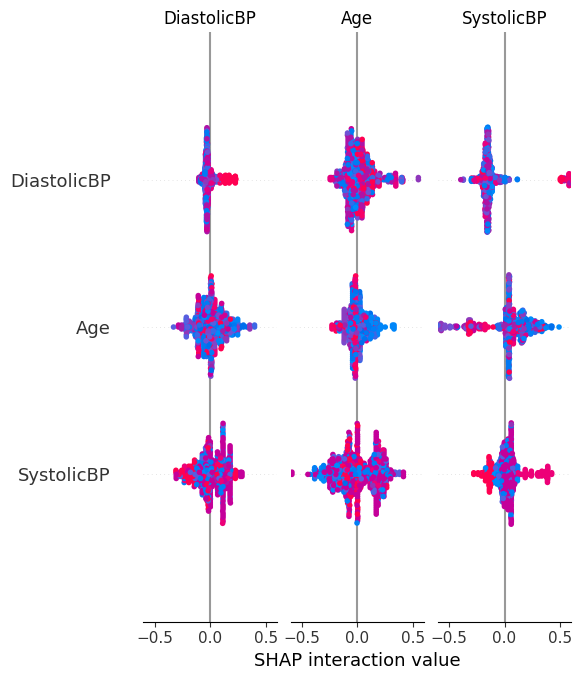

In [32]:
shap.summary_plot(shap_values, X_train)


In [34]:
type(shap_values)


numpy.ndarray

In [35]:
patient_index = 0


In [38]:
print(type(shap_values))
print(len(shap_values))

for i in range(len(shap_values)):
    print(f"Class {i} shap shape:", shap_values[i].shape)

print("X_train shape:", X_train.shape)


<class 'numpy.ndarray'>
811
Class 0 shap shape: (6, 3)
Class 1 shap shape: (6, 3)
Class 2 shap shape: (6, 3)
Class 3 shap shape: (6, 3)
Class 4 shap shape: (6, 3)
Class 5 shap shape: (6, 3)
Class 6 shap shape: (6, 3)
Class 7 shap shape: (6, 3)
Class 8 shap shape: (6, 3)
Class 9 shap shape: (6, 3)
Class 10 shap shape: (6, 3)
Class 11 shap shape: (6, 3)
Class 12 shap shape: (6, 3)
Class 13 shap shape: (6, 3)
Class 14 shap shape: (6, 3)
Class 15 shap shape: (6, 3)
Class 16 shap shape: (6, 3)
Class 17 shap shape: (6, 3)
Class 18 shap shape: (6, 3)
Class 19 shap shape: (6, 3)
Class 20 shap shape: (6, 3)
Class 21 shap shape: (6, 3)
Class 22 shap shape: (6, 3)
Class 23 shap shape: (6, 3)
Class 24 shap shape: (6, 3)
Class 25 shap shape: (6, 3)
Class 26 shap shape: (6, 3)
Class 27 shap shape: (6, 3)
Class 28 shap shape: (6, 3)
Class 29 shap shape: (6, 3)
Class 30 shap shape: (6, 3)
Class 31 shap shape: (6, 3)
Class 32 shap shape: (6, 3)
Class 33 shap shape: (6, 3)
Class 34 shap shape: (6, 3)
Cl

In [40]:
explainer = shap.Explainer(best_model, X_train)
shap_vals = explainer(X_test.iloc[[0]])


In [41]:
shap_text = pd.DataFrame({
    "Feature": X_train.columns,
    "SHAP_Contribution": shap_vals.values[0][:, 2]
}).sort_values(by="SHAP_Contribution", ascending=False)

shap_text


,Feature,SHAP_Contribution
0,Age,-0.000680
2,DiastolicBP,-0.026271
5,HeartRate,-0.030413
4,BodyTemp,-0.039966
1,SystolicBP,-0.080352
3,BS,-0.100663


In [46]:
# Safety imports
import pandas as pd
import numpy as np


In [47]:
# Normal medical ranges
NORMAL_RANGES = {
    "SystolicBP": (90, 120),
    "DiastolicBP": (60, 80),
    "BS": (4.0, 7.8),
    "HeartRate": (60, 100),
    "BodyTemp": (97.0, 99.0),
    "Age": (18, 35)
}


In [52]:
def explain_prediction(model, patient_row, importance_df):
    # Predict probabilities
    probs = model.predict_proba(patient_row.to_frame().T)[0]

    predicted_class = int(np.argmax(probs))

    risk_map = {0: "LOW RISK", 1: "MID RISK", 2: "HIGH RISK"}
    reasons = []

    # Use top 3 important features
    for feature in importance_df["Feature"][:3]:
        value = patient_row[feature]
        low, high = NORMAL_RANGES.get(feature, (None, None))

        if low is not None and value > high:
            reasons.append(f"{feature} is high ({value})")
        elif low is not None and value < low:
            reasons.append(f"{feature} is low ({value})")

    if not reasons:
        reasons.append("most clinical indicators are within normal range")

    explanation = (
        f"The model predicts {risk_map[predicted_class]} because "
        + ", ".join(reasons) + "."
    )

    return explanation


In [53]:
patient = X_test.iloc[0]

explanation_text = explain_prediction(
    best_model,
    patient,
    importance_df
)

print(explanation_text)


The model predicts MID RISK because SystolicBP is high (130.0).


In [50]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_df


,Feature,Importance
3,BS,0.365455
1,SystolicBP,0.183485
0,Age,0.163258
2,DiastolicBP,0.124575
5,HeartRate,0.103958
4,BodyTemp,0.059269
